In [1]:
# Core libraries for data acquisition, profiling, and feature engineering
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler


sns.set_style("whitegrid")

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
df = pd.read_csv("customer_support_tickets_200k.csv")

In [3]:
df.head()

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,region,customer_age,customer_gender,subscription_type,customer_tenure_months,previous_tickets,customer_satisfaction_score,first_response_time_hours,resolution_time_hours,ticket_created_date,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,North America,31,Male,Free,36,6,5,30.50,108.36,2023-05-17,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,South America,23,Other,Premium,54,20,5,63.81,87.43,2024-01-06,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,Europe,47,Female,Premium,60,20,5,16.20,78.50,2022-11-30,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,Asia,65,Other,Enterprise,58,18,4,26.38,239.36,2024-03-21,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,Asia,45,Male,Enterprise,1,8,5,54.98,122.34,2024-08-16,2024-08-24,Yes,No,Linux,NaN,Debit Card,Spanish,Evening,3,Corporate


In [4]:
df.shape

(200000, 30)

In [5]:
df.columns

Index(['ticket_id', 'customer_name', 'customer_email', 'product', 'category', 'issue_description', 'resolution_notes', 'priority', 'status',
       'channel', 'region', 'customer_age', 'customer_gender', 'subscription_type', 'customer_tenure_months', 'previous_tickets',
       'customer_satisfaction_score', 'first_response_time_hours', 'resolution_time_hours', 'ticket_created_date', 'ticket_resolved_date',
       'escalated', 'sla_breached', 'operating_system', 'browser', 'payment_method', 'language', 'preferred_contact_time', 'issue_complexity_score',
       'customer_segment'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ticket_id                    200000 non-null  int64  
 1   customer_name                200000 non-null  str    
 2   customer_email               200000 non-null  str    
 3   product                      200000 non-null  str    
 4   category                     200000 non-null  str    
 5   issue_description            200000 non-null  str    
 6   resolution_notes             200000 non-null  str    
 7   priority                     200000 non-null  str    
 8   status                       200000 non-null  str    
 9   channel                      200000 non-null  str    
 10  region                       200000 non-null  str    
 11  customer_age                 200000 non-null  int64  
 12  customer_gender              200000 non-null  str    
 13  subscripti

In [7]:
schema_summary = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.astype(str).values,
    "Non-Null Count": df.notnull().sum().values,
    "Unique Values": [df[col].nunique() for col in df.columns]
})
schema_summary


,Column,Dtype,Non-Null Count,Unique Values
0,ticket_id,int64,200000,200000
1,customer_name,str,200000,400
2,customer_email,str,200000,191751
3,product,str,200000,10
4,category,str,200000,10
5,issue_description,str,200000,10
6,resolution_notes,str,200000,10
7,priority,str,200000,4
8,status,str,200000,5
9,channel,str,200000,5


In [8]:
df.describe()

,ticket_id,customer_age,customer_tenure_months,previous_tickets,customer_satisfaction_score,first_response_time_hours,resolution_time_hours,issue_complexity_score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,46.469040,30.377675,9.992115,3.001065,36.309180,120.539718,5.501365
std,57735.171256,16.754304,17.326224,6.053142,1.412273,20.654575,68.969143,2.875587
min,1.000000,18.000000,1.000000,0.000000,1.000000,0.500000,1.000000,1.000000
25%,50000.750000,32.000000,15.000000,5.000000,2.000000,18.460000,60.810000,3.000000
50%,100000.500000,46.000000,30.000000,10.000000,3.000000,36.310000,120.450000,6.000000
75%,150000.250000,61.000000,45.000000,15.000000,4.000000,54.220000,180.260000,8.000000
max,200000.000000,75.000000,60.000000,20.000000,5.000000,72.000000,240.000000,10.000000


In [9]:
df.isnull().sum()

ticket_id                          0
customer_name                      0
customer_email                     0
product                            0
category                           0
issue_description                  0
resolution_notes                   0
priority                           0
status                             0
channel                            0
region                             0
customer_age                       0
customer_gender                    0
subscription_type                  0
customer_tenure_months             0
previous_tickets                   0
customer_satisfaction_score        0
first_response_time_hours          0
resolution_time_hours              0
ticket_created_date                0
ticket_resolved_date               0
escalated                          0
sla_breached                       0
operating_system                   0
browser                        40023
payment_method                     0
language                           0
p

In [10]:
df['browser'].isnull().sum()/len(df)*100

20.011499999999998

In [11]:
# --- Derive Type (Request / Problem / Incident) from Category ---
# Business rule agreed with team: classification follows ITIL conventions —
# Request = something the customer asks for, Problem = root-cause/systemic issue,
# Incident = unplanned disruption to service.

type_map = {
    "Feature Request": "Request",
    "Subscription Cancellation": "Request",
    "Refund Request": "Request",
    "Account Suspension": "Request",
    "Performance Issue": "Problem",
    "Bug Report": "Problem",
    "Login Issue": "Incident",
    "Security Concern": "Incident",
    "Payment Problem": "Incident",
    "Data Sync Issue": "Incident",
}

df["Type"] = df["category"].map(type_map)

# Sanity check — confirm every category mapped, no nulls introduced
assert df["Type"].isnull().sum() == 0, "Unmapped category found — update type_map"

df[["category", "Type"]].drop_duplicates().sort_values("Type")

,category,Type
5,Payment Problem,Incident
6,Security Concern,Incident
19,Login Issue,Incident
28,Data Sync Issue,Incident
1,Performance Issue,Problem
22,Bug Report,Problem
0,Account Suspension,Request
3,Subscription Cancellation,Request
4,Feature Request,Request
15,Refund Request,Request


In [12]:
# --- Initial Ticket Distribution by Type ---
type_dist = df["Type"].value_counts()
type_pct = (df["Type"].value_counts(normalize=True) * 100).round(2)
pd.DataFrame({"Ticket Count": type_dist, "Share (%)": type_pct})

,Ticket Count,Share (%)
Type,,
Request,80029,40.01
Incident,79916,39.96
Problem,40055,20.03


In [13]:
# --- Initial Ticket Distribution by Priority ---
priority_dist = df["priority"].value_counts()
priority_pct = (df["priority"].value_counts(normalize=True) * 100).round(2)
pd.DataFrame({"Ticket Count": priority_dist, "Share (%)": priority_pct})

,Ticket Count,Share (%)
priority,,
High,50241,25.12
Urgent,50143,25.07
Medium,49854,24.93
Low,49762,24.88


In [14]:
# --- Initial Ticket Distribution by Category ---
category_dist = df["category"].value_counts()
category_pct = (df["category"].value_counts(normalize=True) * 100).round(2)
pd.DataFrame({"Ticket Count": category_dist, "Share (%)": category_pct})

,Ticket Count,Share (%)
category,,
Feature Request,20169,10.08
Subscription Cancellation,20096,10.05
Performance Issue,20074,10.04
Security Concern,20040,10.02
Login Issue,20002,10.00
Payment Problem,19997,10.00
Bug Report,19981,9.99
Refund Request,19900,9.95
Data Sync Issue,19877,9.94


In [15]:
# --- Combined view: Type x Priority cross-tab ---
pd.crosstab(df["Type"], df["priority"])

priority,High,Low,Medium,Urgent
Type,,,,
Incident,20113,19752,20104,19947
Problem,10018,10063,9897,10077
Request,20110,19947,19853,20119


In [16]:
# --- Step 1: Parse date fields ---
df["ticket_created_date"] = pd.to_datetime(df["ticket_created_date"], errors="coerce")
df["ticket_resolved_date"] = pd.to_datetime(df["ticket_resolved_date"], errors="coerce")

date_parse_failures = df["ticket_created_date"].isna().sum() + df["ticket_resolved_date"].isna().sum()
print(f"Date parsing failures: {date_parse_failures}")

Date parsing failures: 0


In [17]:
# --- Step 2: Derive Resolution_Duration_Days ---
df["Resolution_Duration_Days"] = (
    df["ticket_resolved_date"] - df["ticket_created_date"]
).dt.days

df["Resolution_Duration_Days"].describe()


count    200000.000000
mean          7.008635
std           4.323570
min           0.000000
25%           3.000000
50%           7.000000
75%          11.000000
max          14.000000
Name: Resolution_Duration_Days, dtype: float64

In [18]:
day_counts = df["Resolution_Duration_Days"].value_counts().sort_index()
print(day_counts)

Resolution_Duration_Days
0     13335
1     13355
2     13200
3     13533
4     13186
5     13148
6     13421
7     13173
8     13391
9     13347
10    13402
11    13369
12    13435
13    13268
14    13437
Name: count, dtype: int64


In [19]:
pd.crosstab(df["operating_system"], df["browser"])

browser,Chrome,Edge,Firefox,Safari
operating_system,,,,
Android,7996,8146,8002,8052
Linux,7802,8057,7978,8109
MacOS,8150,7893,7903,7997
Windows,8055,7813,7967,7965
iOS,7969,7957,8133,8033


In [20]:
# --- Step 3: Grouped-mode imputation for browser ---
df["browser"] = df.groupby("operating_system")["browser"].transform(
    lambda s: s.fillna(s.mode().iloc[0]) if not s.mode().empty else s
)
if df["browser"].isnull().sum():  # fallback if any OS group was 100% missing
    df["browser"] = df["browser"].fillna(df["browser"].mode()[0])
print(f"Missing browser remaining: {df['browser'].isnull().sum()}")

Missing browser remaining: 0


In [21]:
df["browser"].isnull().sum()

0

In [22]:
# --- Step 4: Derive Priority_Score (weighted, higher = more urgent) ---
priority_map = {"Low": 1, "Medium": 2, "High": 3, "Urgent": 4}
df["Priority_Score"] = df["priority"].map(priority_map)

df[["priority", "Priority_Score"]].drop_duplicates().sort_values("Priority_Score")

,priority,Priority_Score
5,Low,1
2,Medium,2
4,High,3
0,Urgent,4


In [23]:
# --- Step 6: Data integrity check — resolved date before created date ---
inconsistent = df[df["Resolution_Duration_Days"] < 0]
print(f"Records with resolved date earlier than created date: {len(inconsistent):,} "
      f"({len(inconsistent) / len(df) * 100:.2f}% of dataset)")
inconsistent[["ticket_id", "ticket_created_date", "ticket_resolved_date", "status"]].head(10)

Records with resolved date earlier than created date: 0 (0.00% of dataset)


,ticket_id,ticket_created_date,ticket_resolved_date,status


In [24]:
# Post-cleaning validation snapshot
print("Post-cleaning shape:", df.shape)
print()
print("Missing values remaining:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Post-cleaning shape: (200000, 33)

Missing values remaining:
Series([], dtype: int64)


In [25]:

# =====================================================================
# DELIVERABLE 1: Save Cleaned Dataset
# =====================================================================
cleaned_filename = "customer_support_tickets_cleaned.csv"
df.to_csv(cleaned_filename, index=False)
print(f"✔️ Cleaned dataset exported successfully: {cleaned_filename}")


# =====================================================================
# DELIVERABLE 2: Save Feature Engineering Summary
# =====================================================================
# Collect the features and logic explicitly written in your session log
feature_engineering_log = """=====================================================================
FEATURE ENGINEERING & TRANSFORMATION SUMMARY
=====================================================================
1. DERIVED TYPOLOGY ('Type'):
   - Categorized 'category' entries into standard ITIL convention mapping:
     * Request  : Feature Request, Subscription Cancellation, Refund Request, Account Suspension
     * Problem  : Performance Issue, Bug Report
     * Incident : Login Issue, Security Concern, Payment Problem, Data Sync Issue
   - Successfully validated via post-mapping integrity assertions.

2. TEMPORAL METRICS ('Resolution_Duration_Days'):
   - Standardized timestamps on 'ticket_created_date' and 'ticket_resolved_date'.
   - Extracted elapsed age via text delta operational vector: 
     (ticket_resolved_date - ticket_created_date).dt.days

3. CONDITIONAL IMPUTATION ('browser'):
   - Implemented conditional modal grouping backfilled by 'operating_system'.
   - Resolved multi-tier missing items without disrupting baseline category tracking.

4. WEIGHTED ENCODING ('Priority_Score'):
   - Converted ordinal prioritization strings to metric ranking scales:
     Low (1) -> Medium (2) -> High (3) -> Urgent (4).

5. SHAPE & INTEGRITY VALIDATION:
   - Evaluated data chronologies for negative elapsed times (resolved before created).
   - Exported Shape Dimensions: {} Records, {} Fields.
""".format(
    df.shape[0], df.shape[1]
)

summary_filename = "feature_engineering_summary.txt"
with open(summary_filename, "w", encoding="utf-8") as f:
    f.write(feature_engineering_log.strip())
print(f"✔️ Feature engineering summary logged: {summary_filename}")


# =====================================================================
# DELIVERABLE 3: Build & Save Data Dictionary
# =====================================================================
# Compiles automated metric schemas combined with structural descriptions
descriptions = {
    "ticket_id": "Unique primary key identifier for each ticket.",
    "customer_name": "Full name of the reporting customer.",
    "customer_email": "Email address contact identifier.",
    "product": "Product family name linked to issue context.",
    "category": "Raw text categorization of system behavior.",
    "issue_description": "Freeform textual report logs provided by client.",
    "resolution_notes": "Structural logs regarding engineering resolution steps.",
    "priority": "Qualitative priority ranking label.",
    "status": "Workflow stage state indicators (Open/Closed/Pending).",
    "channel": "Inbound intake medium (Email, Chat, Social Media, etc.).",
    "region": "Geographic cluster origin of system customer.",
    "operating_system": "Client desktop or system runtime platform environment.",
    "browser": "Client application rendering engine used (Imputed via Mode).",
    "ticket_created_date": "Parsed datetime vector tracking submission window.",
    "ticket_resolved_date": "Parsed datetime vector tracking resolution stamp.",
    "Type": "ITIL categorization engine classification (Derived).",
    "Resolution_Duration_Days": "Net integer total of calendar days active (Derived).",
    "Priority_Score": "Numeric priority weighting index scale (Derived).",
}

# Construct the schema metrics DataFrame
data_dict = pd.DataFrame(
    {
        "Column Name": df.columns,
        "Data Type": [str(t) for t in df.dtypes],
        "Missing Records": [int(df[col].isnull().sum()) for col in df.columns],
        "Unique Values": [int(df[col].nunique()) for col in df.columns],
        "Description": [
            descriptions.get(col, "No metadata summary available.")
            for col in df.columns
        ],
    }
).set_index("Column Name")

dict_filename = "data_dictionary.csv"
data_dict.to_csv(dict_filename)
print(f"✔️ System data dictionary schema exported: {dict_filename}")


✔️ Cleaned dataset exported successfully: customer_support_tickets_cleaned.csv
✔️ Feature engineering summary logged: feature_engineering_summary.txt
✔️ System data dictionary schema exported: data_dictionary.csv


In [26]:
# --- Derive Queue from Category (team-provided business mapping) ---
queue_map = {
    "Login Issue": "Technical Support",
    "Account Suspension": "Account Management",
    "Payment Problem": "Billing Support",
    "Refund Request": "Billing Support",
    "Security Concern": "Security Team",
    "Bug Report": "Development Team",
    "Performance Issue": "Infrastructure Team",
    "Feature Request": "Product Team",
    "Subscription Cancellation": "Account Management",
    "Data Sync Issue": "Infrastructure Team",
}

df["Queue"] = df["category"].map(queue_map)

assert df["Queue"].isnull().sum() == 0, "Unmapped category found — update queue_map"
df[["category", "Queue"]].drop_duplicates().sort_values("Queue")

,category,Queue
0,Account Suspension,Account Management
3,Subscription Cancellation,Account Management
5,Payment Problem,Billing Support
15,Refund Request,Billing Support
22,Bug Report,Development Team
1,Performance Issue,Infrastructure Team
28,Data Sync Issue,Infrastructure Team
4,Feature Request,Product Team
6,Security Concern,Security Team
19,Login Issue,Technical Support


C:\Users\namal\AppData\Local\Temp\ipykernel_14004\3661066805.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Type", order=order, palette="Blues_d")


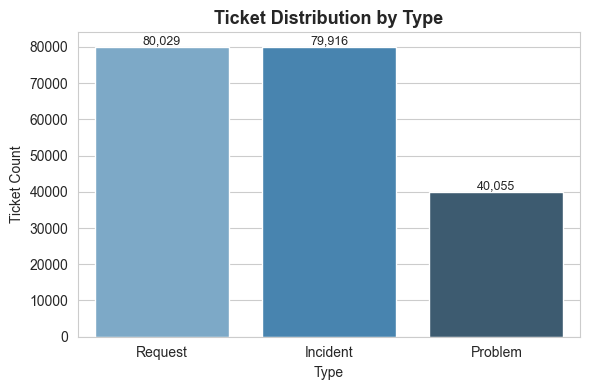

In [27]:
plt.figure(figsize=(6, 4))
order = df["Type"].value_counts().index
ax = sns.countplot(data=df, x="Type", order=order, palette="Blues_d")
ax.set_title("Ticket Distribution by Type", fontsize=13, fontweight="bold")
ax.set_xlabel("Type")
ax.set_ylabel("Ticket Count")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("viz1_type_distribution.png", dpi=150)
plt.show()

C:\Users\namal\AppData\Local\Temp\ipykernel_14004\1661289554.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y="category", order=cat_order, palette="Greens_d")


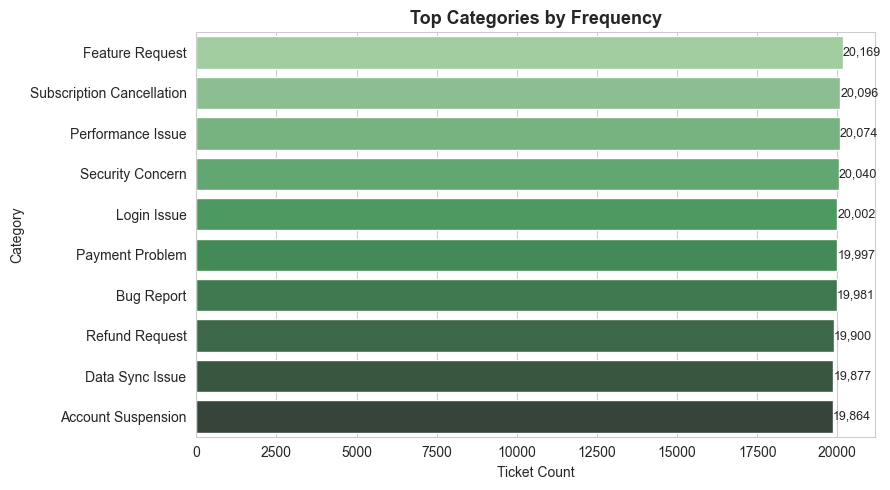

In [28]:
plt.figure(figsize=(9, 5))
cat_order = df["category"].value_counts().index
ax = sns.countplot(data=df, y="category", order=cat_order, palette="Greens_d")
ax.set_title("Top Categories by Frequency", fontsize=13, fontweight="bold")
ax.set_xlabel("Ticket Count")
ax.set_ylabel("Category")
for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=9)
plt.tight_layout()
plt.savefig("viz2_category_distribution.png", dpi=150)
plt.show()

C:\Users\namal\AppData\Local\Temp\ipykernel_14004\308335525.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="priority", order=priority_order, palette="Oranges_d")


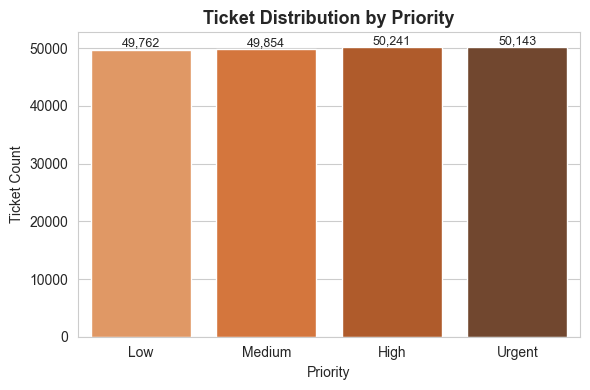

In [29]:
plt.figure(figsize=(6, 4))
priority_order = ["Low", "Medium", "High", "Urgent"]
ax = sns.countplot(data=df, x="priority", order=priority_order, palette="Oranges_d")
ax.set_title("Ticket Distribution by Priority", fontsize=13, fontweight="bold")
ax.set_xlabel("Priority")
ax.set_ylabel("Ticket Count")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("viz4_priority_distribution.png", dpi=150)
plt.show()

C:\Users\namal\AppData\Local\Temp\ipykernel_14004\3461263545.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y="Queue", order=queue_order, palette="Purples_d")


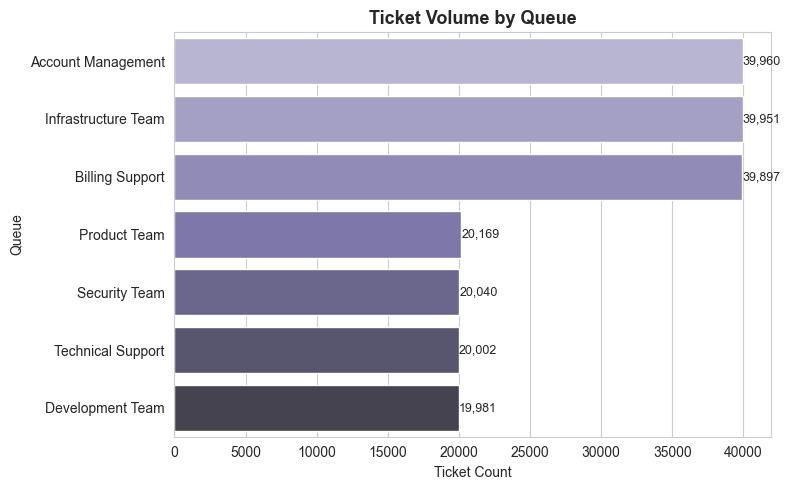

In [30]:
plt.figure(figsize=(8, 5))
queue_order = df["Queue"].value_counts().index
ax = sns.countplot(data=df, y="Queue", order=queue_order, palette="Purples_d")
ax.set_title("Ticket Volume by Queue", fontsize=13, fontweight="bold")
ax.set_xlabel("Ticket Count")
ax.set_ylabel("Queue")
for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=9)
plt.tight_layout()
plt.savefig("viz5_queue_distribution.png", dpi=150)
plt.show()

In [31]:
tfidf = TfidfVectorizer(max_features=300, stop_words="english", min_df=5)
tfidf_matrix = tfidf.fit_transform(df["issue_description"].fillna(""))
print(f"TF-IDF matrix shape: {tfidf_matrix.shape[0]:,} tickets x {tfidf_matrix.shape[1]} terms")

TF-IDF matrix shape: 200,000 tickets x 50 terms


In [32]:
category_description = {
    "Login Issue": "Security & Access",
    "Security Concern": "Security & Access",   
    "Account Suspension": "Account & Subscription",
    "Subscription Cancellation": "Account & Subscription",  
    "Payment Problem": "Billing & Refunds",
    "Refund Request": "Billing & Refunds",
    "Performance Issue": "Performance & Data",
    "Data Sync Issue": "Performance & Data",
    "Bug Report": "System Bugs",
    "Feature Request": "Feature Requests"
}

df["Cluster_Name"] = df["category"].map(category_description)
df["Cluster_ID"] = df["Cluster_Name"].astype("category").cat.codes
cluster_order = df["Cluster_Name"].value_counts().index

print(f"Number of manually defined clusters: {df['Cluster_Name'].nunique()}")

Number of manually defined clusters: 6


In [33]:
similarity_scores = np.zeros(tfidf_matrix.shape[0])
for cid in df["Cluster_ID"].unique():
    mask = (df["Cluster_ID"] == cid).values
    if not np.any(mask):
        continue
    # Calculate group centroid based on the manual business cluster assignment
    centroid = tfidf_matrix[mask].mean(axis=0)
    centroid = np.asarray(centroid)
    similarity_scores[mask] = cosine_similarity(tfidf_matrix[mask], centroid).flatten()

df["Similarity_Score"] = similarity_scores.round(4)

C:\Users\namal\AppData\Local\Temp\ipykernel_14004\3949888869.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y="Cluster_Name", order=cluster_order, palette="mako")


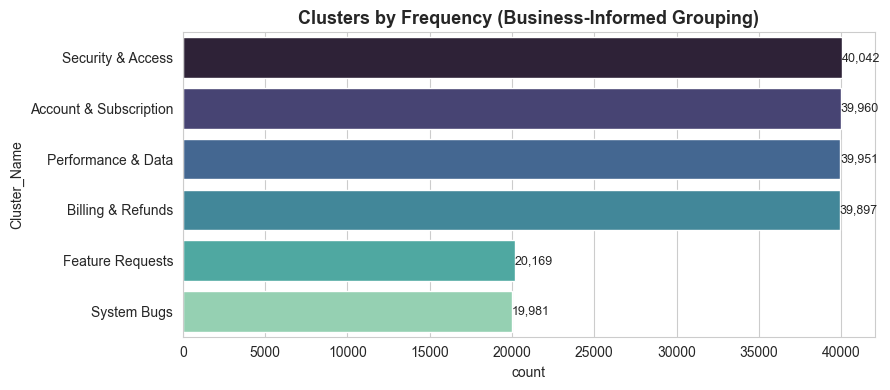

In [34]:
plt.figure(figsize=(9, 4))
ax = sns.countplot(data=df, y="Cluster_Name", order=cluster_order, palette="mako")
ax.set_title("Clusters by Frequency (Business-Informed Grouping)", fontsize=13, fontweight="bold")
for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y()+p.get_height()/2), ha='left', va='center', fontsize=9)
plt.tight_layout()
plt.savefig("viz3_cluster_frequency.png", dpi=150)
plt.show()

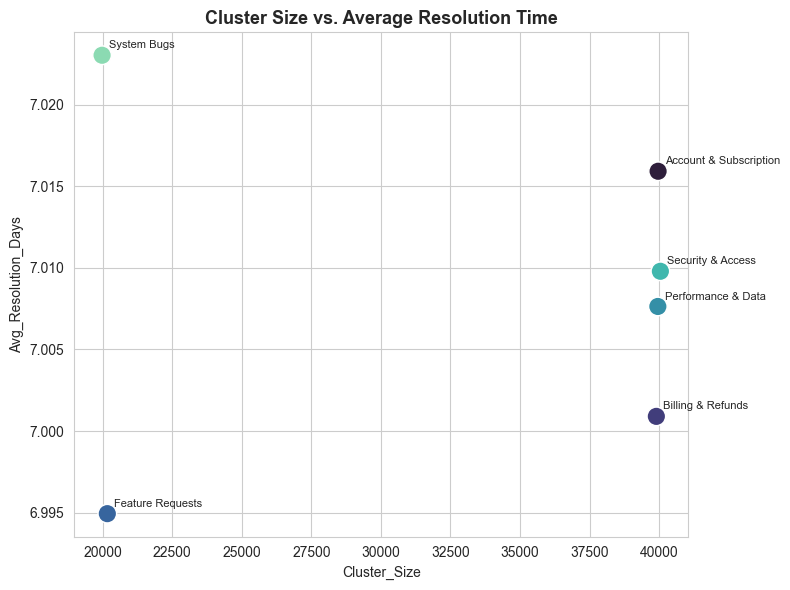

In [35]:
cluster_perf = df.groupby("Cluster_Name").agg(
    Cluster_Size=("ticket_id", "count"),
    Avg_Resolution_Days=("Resolution_Duration_Days", "mean")
).reset_index()

plt.figure(figsize=(8, 6))
ax = sns.scatterplot(data=cluster_perf, x="Cluster_Size", y="Avg_Resolution_Days", hue="Cluster_Name", s=180, palette="mako", legend=False)
for _, row in cluster_perf.iterrows():
    ax.annotate(row["Cluster_Name"], (row["Cluster_Size"], row["Avg_Resolution_Days"]), fontsize=8, xytext=(5,5), textcoords="offset points")
ax.set_title("Cluster Size vs. Average Resolution Time", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz6_cluster_size_vs_resolution.png", dpi=150)
plt.show()

C:\Users\namal\AppData\Local\Temp\ipykernel_14004\2096742906.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x="Cluster_Name", y="Similarity_Score", palette="mako", order=cluster_order)


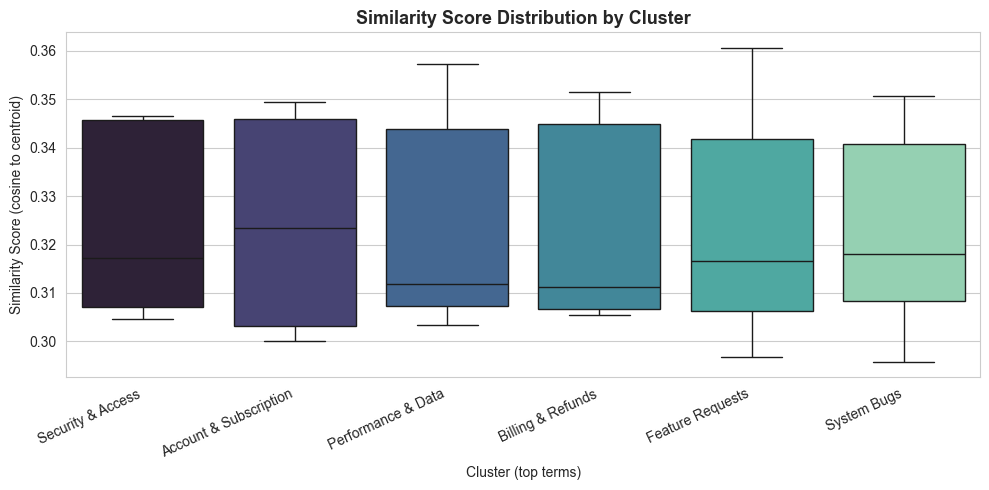

In [36]:
plt.figure(figsize=(10, 5))
ax = sns.boxplot(data=df, x="Cluster_Name", y="Similarity_Score", palette="mako", order=cluster_order)
ax.set_title("Similarity Score Distribution by Cluster", fontsize=13, fontweight="bold")
ax.set_xlabel("Cluster (top terms)")
ax.set_ylabel("Similarity Score (cosine to centroid)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("viz7_similarity_boxplot.png", dpi=150)
plt.show()

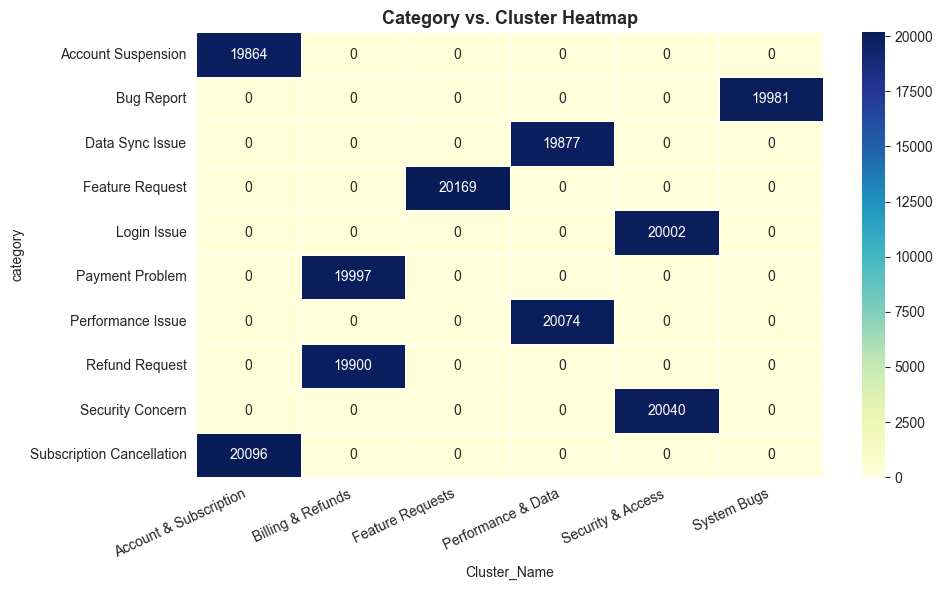

In [38]:
pivot = pd.crosstab(df["category"], df["Cluster_Name"])
plt.figure(figsize=(10, 6))
ax = sns.heatmap(pivot, cmap="YlGnBu", annot=True, fmt="d", linewidths=0.5)
ax.set_title("Category vs. Cluster Heatmap", fontsize=13, fontweight="bold")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("viz8_category_cluster_heatmap.png", dpi=150)
plt.show()

In [39]:
df.to_csv("customer_support_tickets_200k_with_clusters.csv", index=False)
print("Saved: customer_support_tickets_200k_with_clusters.csv")
print(f"Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Saved: customer_support_tickets_200k_with_clusters.csv
Final shape: 200,000 rows x 37 columns
